In [ ]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import xarray as xr
xr.set_options(keep_attrs=True)
import numpy as np
np.seterr(divide='ignore', invalid='ignore')
import metpy.calc as mp
from metpy.units import units

In [2]:
def specific_humidity_from_rh(RH, T, p):
    """
    Calculate the specific humidity of an air parcel given relative humidity and temperature
    !Requires metpy!

    Inputs:
    ----------
    T = air temperature, K (array)
    RH = relative humidity (array)
    p = pressure, Pa (array)

    Outputs:
    ----------
    qs = specific humidity, kg/kg

    Constants:
    ----------
    Rd = specific gas constant dry air, J kg-1 K-1
    Rv = specific gas constant water vapor, J kg-1 K-1
    """
    # set constants
    Rd = 287.05 # J kg-1 K-1
    Rv = 461.50 # J kg−1 K−1
    # first, determine what the saturation vapor pressure is for the given temperature
    esT = mp.saturation_vapor_pressure(T)
    # then, what the actual vapor pressure is for the given relative humidity and temperature
    e = RH * esT
    # calculate mass mixing ratio of water vapor to dry air based on the vapor pressure
    w = (e * Rd) / (Rv * (p - e))
    # finally, solve for specific humidity
    q = w / (w + 1) 
    
    return q
    
    

In [3]:
# product keys
keys=['flor']
flor_simNames=['ctrl','hitopo']
flor_runs=['ctrl','hitopo']

# store file paths in dictionary
dpath0='/discover/nobackup/projects/giss/baldwin_nip/dmkumar' # top level data directory
files={ 'flor' : { 'ctrl' : {}, 'hitopo' : {} } }

for key in ['flor']:
    for i,run in enumerate(flor_runs):
        simName=flor_simNames[i]
        files[key][run]['rh_ref'] = f'{dpath0}/FLOR/{simName}/pi/flor.{simName}.rh_ref.monthly.nc'
        files[key][run]['t_ref'] = f'{dpath0}/FLOR/{simName}/pi/flor.{simName}.t_ref.monthly.nc'
        files[key][run]['ps'] = f'{dpath0}/FLOR/{simName}/pi/flor.{simName}.ps.monthly.nc'

In [4]:
### +++ LOAD DATA +++ ###

# lat lon bounds
latmin = 10
latmax = 80
lonmin = 200
lonmax = 300
n_years= 100
n_keep = -1 * (n_years * 12) # number of time steps to keep in months

# initialize dictionaries
dat = { 'flor' : { 'ctrl' : {}, 'hitopo' : {} } }

flor_varns = ['rh_ref','t_ref','ps']

print('Working on...')
for i,key in enumerate(['flor']):
    print(f'{key}')
    if key == 'flor':
        for run in flor_runs:
            # read in diagnostics
            for varn in flor_varns:
                dat[key][run][varn] = xr.open_dataset(files[key][run][varn])[varn][n_keep:].sel(grid_xt=slice(lonmin,lonmax), grid_yt=slice(latmin,latmax)) # only use data from last 100 years

print('Done.')

Working on...
flor
Done.


In [5]:
### +++ CALCULATE Q +++ ###

qs = { 'flor' : {} }

for key in ['flor']:
    for run in flor_runs:
        rh = dat[key][run]['rh_ref']/100
        t = dat[key][run]['t_ref'] * units.degK # add metpy units
        t.attrs["units"] = "K"
        p = dat[key][run]['ps'] * units.Pa # add metpy units
        qs[key][run] = specific_humidity_from_rh(rh, t, p)



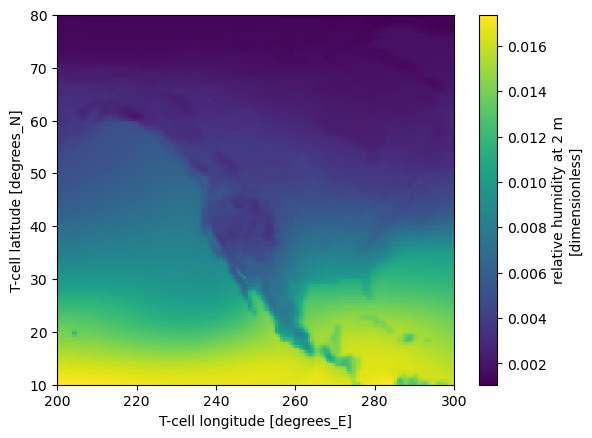

In [6]:
# sanity check plot
qs['flor']['ctrl'].mean(dim='time').plot()

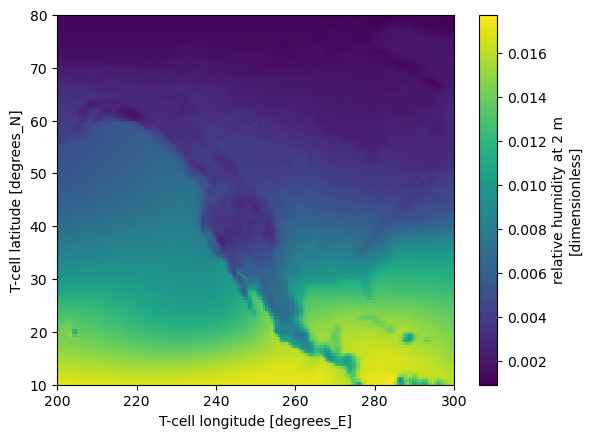

In [7]:
# sanity check plot
qs['flor']['hitopo'].mean(dim='time').plot()

In [20]:
 # save nc files
for key in ['flor']:
    for i,run in enumerate(flor_runs):
        qs[key][run].name = 'q_ref'
        qs[key][run].attrs['long_name'] = 'surface (2m) specific humidity'
        qs[key][run].attrs['units'] = 'kg/kg'
        qs[key][run].attrs['method'] = 'calculated from relative humidity'
        qs[key][run].to_netcdf(f'{dpath0}/FLOR/{run}/pi/{key}.{run}.q_ref.monthly.nc', mode='w')